# Analysis of Dunking Biscuits in Tea 


## Programming Project 2 (SCIFM0002)


### Shubham Shinde (2628052) 


## Import Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import curve_fit
from scipy.ndimage import uniform_filter1d
from scipy.stats import gaussian_kde


from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     GridSearchCV, StratifiedKFold, KFold,
                                     learning_curve)

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, r2_score, mean_squared_error,
                             mean_absolute_error, brier_score_loss)
from sklearn.calibration import calibration_curve



import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

Defining the biscuit colours of easy understaning while plotting 


In [2]:
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 110})

biscuit_colour = {'Rich Tea': '#f6c453', 'Hobnob': '#e85d4a', 'Digestive': '#7c4f3a'}
biscuits = ['Rich Tea', 'Hobnob', 'Digestive']



ACCENT = '#2d8aa6'     # defining accent colours for other plots
HIGHLIGHT = '#e85d4a'
NEUTRAL = '#5a6573'

## Load the data

In [3]:
dunk = pd.read_csv('data/dunking-data.csv')

micro = pd.read_csv('data/microscopy-data.csv')


tr = {}
for i in (1, 2, 3):
    tr[f'tr{i}'] = pd.read_csv(f'data/tr-{i}.csv')  



# constants for the time resolved 
gamma_tr = 6.78e-2   # in N/m
phi_tr = 1.45        # in rad
eta_tr = 9.93e-4     # in Pa s


print('dunkingdata:', dunk.shape, dict(dunk['biscuit'].value_counts()))

print('microscopy: ', micro.shape)

for k, v in tr.items():
    print(k + ':', v.shape)

dunkingdata: (3000, 6) {'Digestive': np.int64(1000), 'Hobnob': np.int64(1000), 'Rich Tea': np.int64(1000)}
microscopy:  (500, 6)
tr1: (100, 3)
tr2: (100, 3)
tr3: (100, 3)


## Exploratory Data Analysis(EDA)

In [4]:
dunk.head()

,gamma,phi,eta,L,t,biscuit
0,0.073897,1.333006,0.000999,0.011196,19.362214,Digestive
1,0.080946,1.476758,0.001012,0.005894,11.852589,Digestive
2,0.087408,1.477141,0.000984,0.009249,24.793669,Digestive
3,0.070793,1.502001,0.001002,0.003774,16.292780,Hobnob
4,0.058917,1.548274,0.001004,0.002291,13.662271,Hobnob


In [5]:
dunk.describe().round(4)

,gamma,phi,eta,L,t
count,3000.0000,3000.0000,3000.000,3000.0000,3000.0000
mean,0.0732,1.4433,0.001,0.0062,19.8487
std,0.0100,0.0949,0.000,0.0032,5.8095
min,0.0403,1.0163,0.001,0.0002,10.0139
25%,0.0666,1.3885,0.001,0.0040,14.6758
50%,0.0732,1.4631,0.001,0.0058,19.8592
75%,0.0799,1.5175,0.001,0.0081,24.7761
max,0.1046,1.5706,0.001,0.0192,29.9920


Distributions of the raw inputs

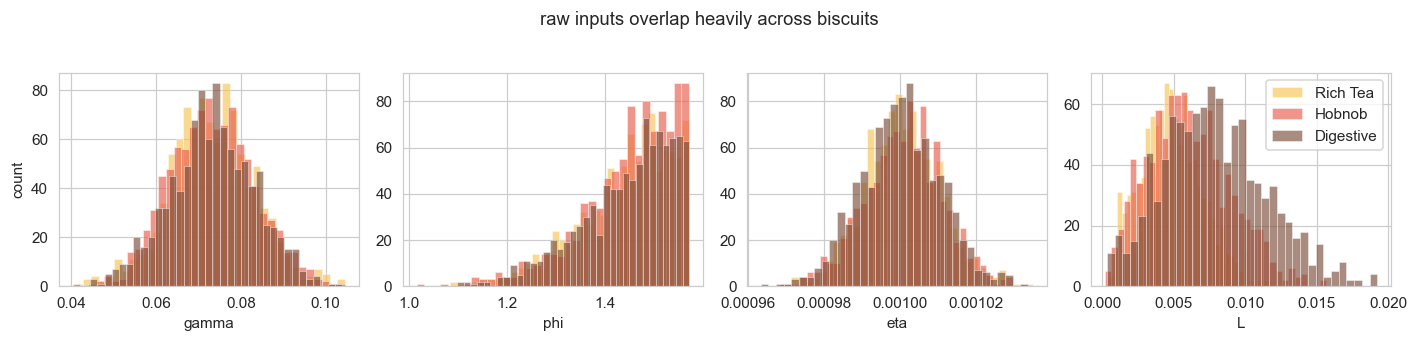

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(13, 3))

for ax, col in zip(axes, ['gamma', 'phi', 'eta', 'L']):
    for b in biscuits:
        ax.hist(dunk.loc[dunk['biscuit'] == b, col], bins=35, alpha=0.65,
                color=biscuit_colour[b], label=b,
                edgecolor='white', linewidth=0.4)
    ax.set_xlabel(col)

axes[0].set_ylabel('count')
axes[-1].legend()

fig.suptitle('raw inputs overlap heavily across biscuits', y=1.02)

plt.tight_layout()
plt.show()


Plotting the four variables to know if any single variable perfectly separated the biscuits, classification would be easy.

but nope, they all overlap too much! 

 # Section 1 - Basic Analysis

### Washburn derived pore radius
So, rearranging washburn gives an effective pore radius for every measurement:

$$r_\text{eff} = \frac{2\eta L^2}{\gamma t \cos\varphi}$$



In [8]:
dunk['r_eff'] = 2 * dunk['eta'] * dunk['L']**2 / (dunk['gamma'] * dunk['t'] * np.cos(dunk['phi'])) # Washburn equation


print(dunk.groupby('biscuit')['r_eff'].describe()[['mean', 'std', 'min', 'max']] * 1e9)

                 mean        std         min         max
biscuit                                                 
Digestive  802.126065  59.642158  676.698057  936.178507
Hobnob     500.307362  80.793701  233.742235  776.362760
Rich Tea   302.058493  50.683623  132.884851  461.752938


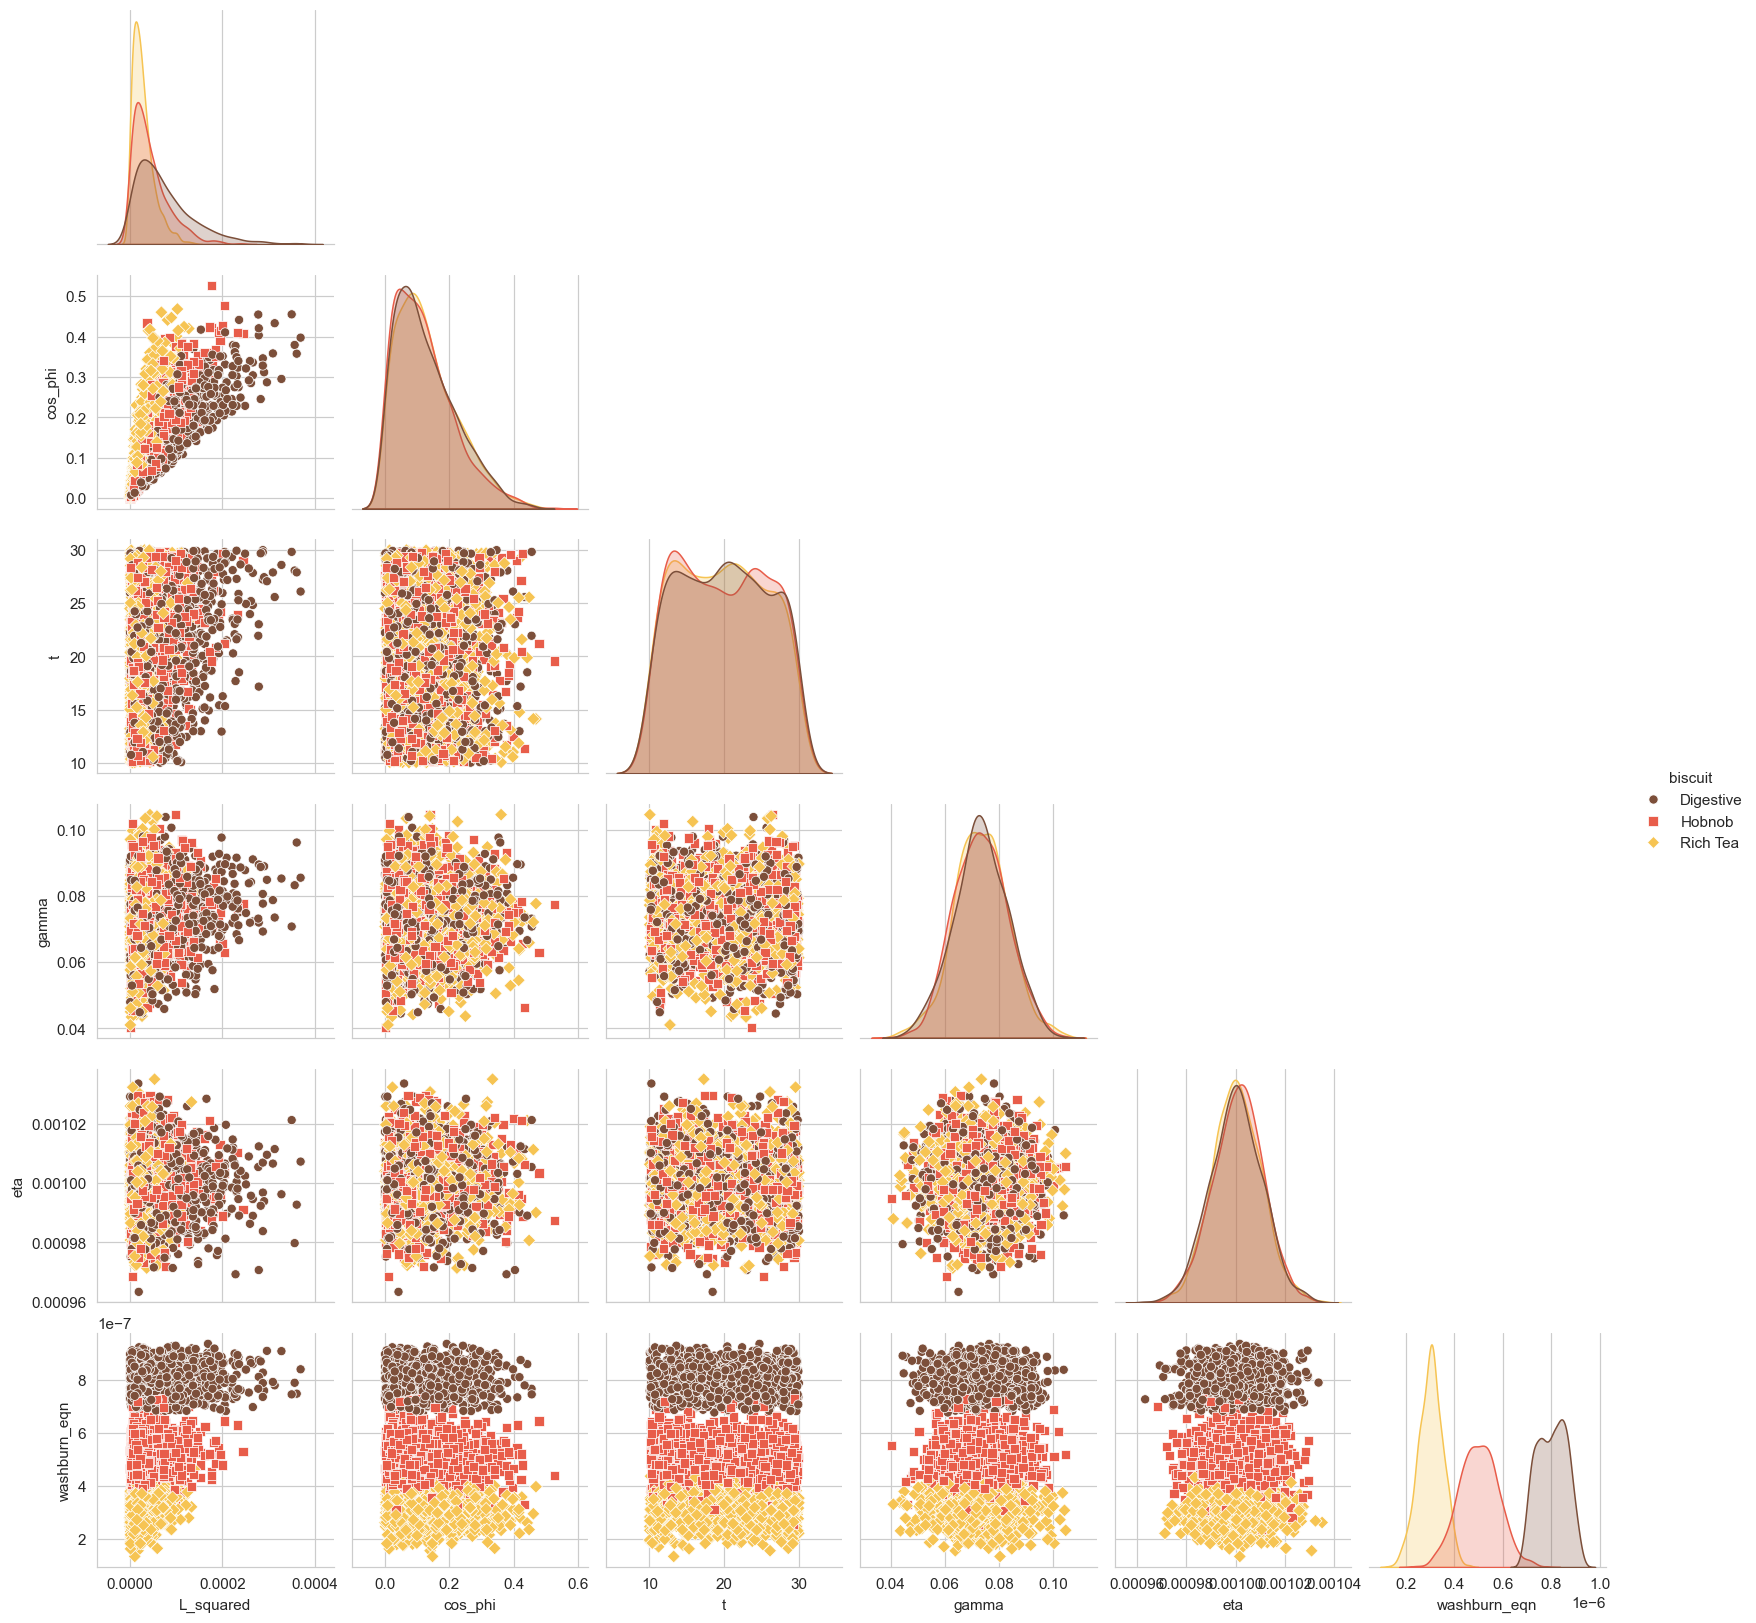

In [54]:
dunk['L_squared'] = dunk['L']**2
dunk['cos_phi'] = np.cos(dunk['phi'])
dunk['washburn_eqn'] = 2 * dunk['eta'] * dunk['L']**2 / (dunk['gamma'] * dunk['t'] * np.cos(dunk['phi']))


pair_cols = ['L_squared', 'cos_phi', 't', 'gamma', 'eta', 'washburn_eqn', 'biscuit']
sns.pairplot(dunk[pair_cols], diag_kind='kde', hue='biscuit',
             corner=True, markers=['o', 's', 'D'], palette=biscuit_colour)
plt.show()

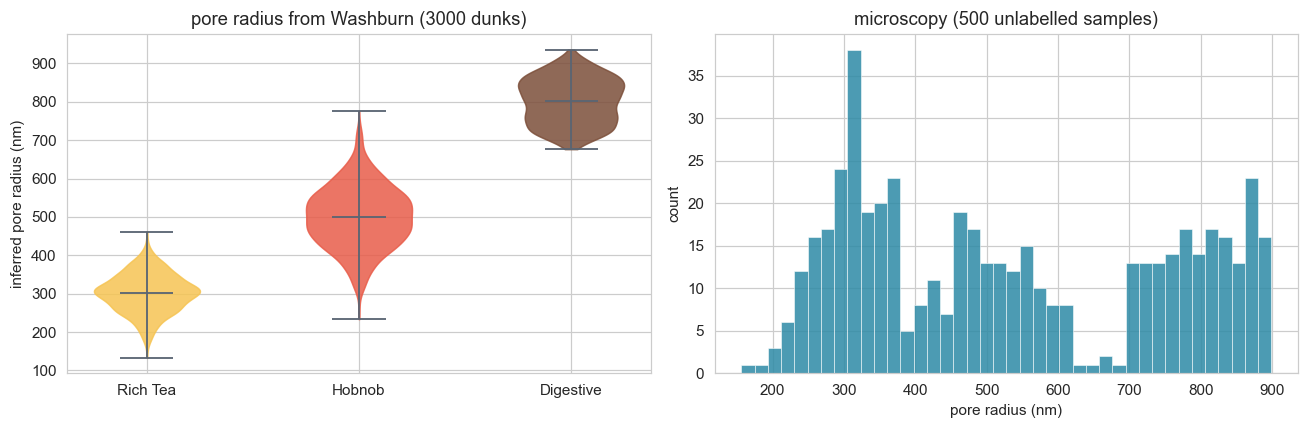

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# using violin plot per biscuit
data = [dunk.loc[dunk['biscuit'] == b, 'r_eff'].values * 1e9 for b in biscuits]


parts = axes[0].violinplot(data, showmeans=True)


for pc, b in zip(parts['bodies'], biscuits):
    pc.set_facecolor(biscuit_colour[b])
    pc.set_edgecolor(biscuit_colour[b])
    pc.set_alpha(0.85)



for key in ('cmeans', 'cmins', 'cmaxes', 'cbars'):
    parts[key].set_edgecolor(NEUTRAL)
    parts[key].set_linewidth(1.2)
axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(biscuits)
axes[0].set_ylabel('inferred pore radius (nm)')
axes[0].set_title('pore radius from Washburn (3000 dunks)')




# microscopy histogram for cross check
axes[1].hist(micro['r'] * 1e9, bins=40, color=ACCENT,
             alpha=0.85, edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('pore radius (nm)')
axes[1].set_ylabel('count')
axes[1].set_title('microscopy (500 unlabelled samples)')


plt.tight_layout()
plt.show()

So, three distinct violin plots show pore radii around 300 nm (Rich Tea), 500 nm (Hobnob), and 800 nm (Digestive). 

The independent microscopy histogram (right side, no biscuit labels) shows the same three peaks over the same range.

 which strong cross validation check 

## Does Washburn actually work?

The microscopy data measures all variables directly, including r. 

So I can predict L from the equation without fitting and check how well it matches the observed L.

In [ ]:
def washburn_l(t, r, gamma, phi, eta):
    """
    Compute the Washburn capillary rise distance.

    Returns L(t) = sqrt(gamma * r * cos(phi) * t / (2 * eta)).

    """
    return np.sqrt(gamma * r * np.cos(phi) * t / (2 * eta))


l_pred = washburn_l(micro['t'], micro['r'], micro['gamma'], micro['phi'], micro['eta'])

r2 = r2_score(micro['L'], l_pred)

rmse = np.sqrt(mean_squared_error(micro['L'], l_pred))

print('R^2  = {:.4f}'.format(r2))
print('RMSE = {:.1f} um'.format(rmse * 1e6))


R^2  = 0.9996
RMSE = 64.3 um


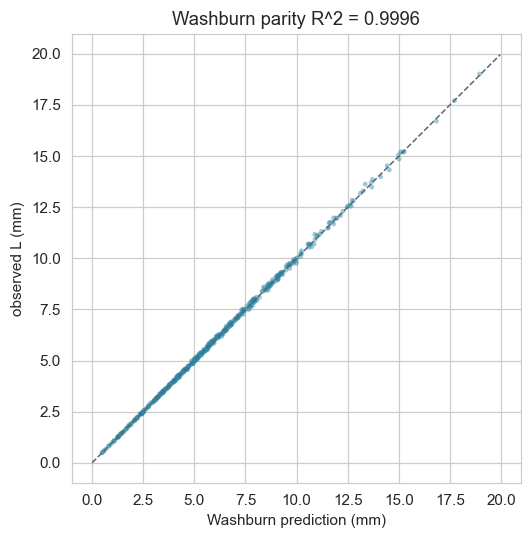

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(l_pred * 1e3, micro['L'] * 1e3, s=10, alpha=0.45,
           color=ACCENT, edgecolor='none')

lim = [0, max(l_pred.max(), micro['L'].max()) * 1.05 * 1e3]

ax.plot(lim, lim, '--', color=NEUTRAL, lw=1)
ax.set_xlabel('Washburn prediction (mm)')
ax.set_ylabel('observed L (mm)')
ax.set_title('Washburn parity R^2 = {:.4f}'.format(r2))
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

The Washburn equation is almost exact when all five inputs are known.  

Any later "failure" comes from missing information, not knowing r.

## Fitting the unknown TR samples

In [ ]:
def fit_one_tr(df, gamma, phi, eta, n_boot=2000):
    """
    Fit r from a single (t, L, dL) dataset using weighted least squares.
    
    A quick linear fit to L^2 vs t gives a rough r0, then curve_fit refines it.
    
    Bootstrap resampling (n_boot) adds a 95% CI, and I also compute reduced chi^2.
    
    Returns a dict containing r, bootstrap stats, chi2_red, and the raw arrays.
    
    """


    t = df['t'].values
    l = df['L'].values
    dl = df['dL'].values



    # get an initial guess by fitting L^2 vs t (Washburn is linear in t)
    slope0 = np.polyfit(t, l**2, 1)[0]
    r0 = max(2 * eta * slope0 / (gamma * np.cos(phi)), 1e-9)


    def model(t_, r_):
        return washburn_l(t_, r_, gamma, phi, eta)

    popt, pcov = curve_fit(model, t, l, p0=[r0], sigma=dl, absolute_sigma=True)
    r_hat = popt[0]

    resid = (l - model(t, r_hat)) / dl
    chi2_red = np.sum(resid**2) / (len(t) - 1)




    # bootstrap for uncertainty estimate
    rng = np.random.default_rng(42)

    samples = []
    
    for _ in range(n_boot):
        idx = rng.integers(0, len(t), size=len(t))

        try:
            p, _ = curve_fit(model, t[idx], l[idx], p0=[r_hat],
                             sigma=dl[idx], absolute_sigma=True, maxfev=2000)
            samples.append(p[0])

        except Exception:
            pass
    samples = np.array(samples)




    return {'r': r_hat,
            'boot_mean': samples.mean(),
            'boot_std': samples.std(ddof=1),
            'ci95': (np.quantile(samples, 0.025), np.quantile(samples, 0.975)),
            'chi2_red': chi2_red,
            't': t, 'l': l, 'dl': dl,}


Running the fit on all three files

In [13]:
fits = {}
for name, df in tr.items():
    fits[name] = fit_one_tr(df, gamma_tr, phi_tr, eta_tr)


print('{:<5}  {:<18}  {:<10}  {}'.format('file', 'r (nm)', 'chi2_red', '95% CI (nm)'))

for name, f in fits.items():
    ci_lo = f['ci95'][0] * 1e9
    ci_hi = f['ci95'][1] * 1e9
    
    print('{:<5}  {:6.1f} +- {:<6.1f}  {:<10.2f}  [{:.1f}, {:.1f}]'.format(
        name, f['r'] * 1e9, f['boot_std'] * 1e9, f['chi2_red'], ci_lo, ci_hi))


file   r (nm)              chi2_red    95% CI (nm)
tr1     518.6 +- 3.1     1.07        [512.0, 523.7]
tr2     280.3 +- 3.0     0.82        [275.0, 286.5]
tr3    1004.8 +- 7.1     5.83        [990.1, 1012.0]


tr1 and tr2 have reduced X^2 = 1, which is perfect fits. 

tr3's reduced X^2 is ~ 5.8, which i will dig into in the advanced section. 

The radius itself is unambiguous, bootstrap CI is tight.

### Match each fit to the closest biscuit

In [14]:
mean_r = dunk.groupby('biscuit')['r_eff'].mean().to_dict()


def closest_biscuit(r):
    """
    Return the biscuit whose mean pore radius is closest to r.
    
    """
    return min(mean_r, key=lambda b: abs(mean_r[b] - r))



guess = {}
for name, f in fits.items():
    guess[name] = closest_biscuit(f['r'])


for k, v in guess.items():
    print('{} = {}  (r = {:.0f} nm, biscuit mean = {:.0f} nm)'.format(
        k, v, fits[k]['r'] * 1e9, mean_r[v] * 1e9))


tr1 = Hobnob  (r = 519 nm, biscuit mean = 500 nm)
tr2 = Rich Tea  (r = 280 nm, biscuit mean = 302 nm)
tr3 = Digestive  (r = 1005 nm, biscuit mean = 802 nm)


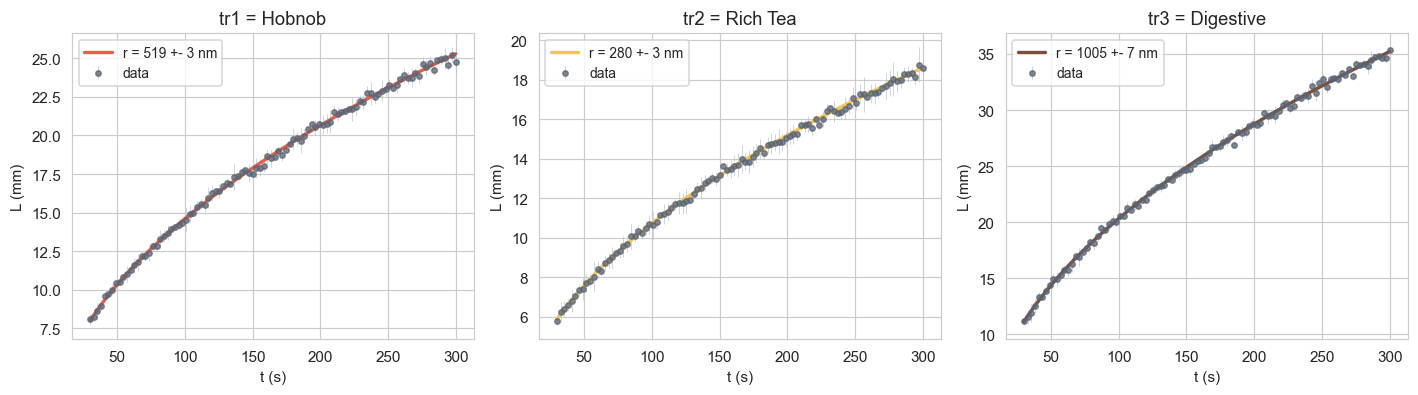

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))


for ax, (name, f) in zip(axes, fits.items()):
    biscuit = guess[name]
    c = biscuit_colour[biscuit]


    t_dense = np.linspace(f['t'].min(), f['t'].max(), 200)
    ax.errorbar(f['t'], f['l'] * 1e3, yerr=f['dl'] * 1e3,
                fmt='o', ms=3.5, color=NEUTRAL, ecolor='#bcc3cc',
                elinewidth=0.6, alpha=0.75, label='data')
    ax.plot(t_dense,
            washburn_l(t_dense, f['r'], gamma_tr, phi_tr, eta_tr) * 1e3,
            color=c, lw=2.2,
            label='r = {:.0f} +- {:.0f} nm'.format(f['r'] * 1e9, f['boot_std'] * 1e9))
    ax.set_xlabel('t (s)')
    ax.set_ylabel('L (mm)')
    ax.set_title('{} = {}'.format(name, biscuit))
    ax.legend(fontsize=9)


plt.tight_layout()
plt.show()

Plot shows the fits with their data,three panels, one per file.

## Classification

I try to identify which biscuit was dunked using only the measured variables. 


Two classifiers are tested - logistic regression and random forest.

Each trained twice: once on the five raw measurements alone, and once with the Washburn derived pore radius added as an extra feature. 

Performance is measured by 5 fold cross-validation (splitting the 3000 dunks into five rounds so every sample gets tested) and confirmed on a separate 20% held out test set the model never saw during training.

In [16]:
raw_feats = ['gamma', 'phi', 'eta', 'L', 't']
phys_feats = raw_feats + ['r_eff']
y = dunk['biscuit']



def make_clf(kind):

    """
    Return a scaling and classifier pipeline. kind is 'logreg' or 'rf'.
    
    """

    if kind == 'logreg':
        clf = LogisticRegression(max_iter=5000, random_state=42)

    else:
        clf = RandomForestClassifier(n_estimators=200, min_samples_leaf=2,
                                     random_state=42, n_jobs=1)
        
    return Pipeline([('scale', StandardScaler()), ('clf', clf)])

In [17]:
configs = [('logreg / raw',     make_clf('logreg'), dunk[raw_feats]),
           ('logreg / + r_eff', make_clf('logreg'), dunk[phys_feats]),
           ('rf / raw',         make_clf('rf'),     dunk[raw_feats]),
           ('rf / + r_eff',     make_clf('rf'),     dunk[phys_feats])]



results = []

fitted = {}

for name, clf, x in configs:
    
    cv = cross_val_score(clf, x, y,
                         cv=StratifiedKFold(5, shuffle=True, random_state=42),
                         scoring='accuracy', n_jobs=1)
    
    xtr, xte, ytr, yte = train_test_split(x, y, test_size=0.2, stratify=y,
                                          random_state=42)
    
    clf.fit(xtr, ytr)
    test_acc = accuracy_score(yte, clf.predict(xte))
    fitted[name] = (clf, xte, yte)
    results.append({'model': name,
                    'CV': '{:.3f} +- {:.3f}'.format(cv.mean(), cv.std()),
                    'test': '{:.3f}'.format(test_acc)})


pd.DataFrame(results)


,model,CV,test
0,logreg / raw,0.739 +- 0.008,0.752
1,logreg / + r_eff,0.953 +- 0.010,0.957
2,rf / raw,0.809 +- 0.008,0.828
3,rf / + r_eff,0.952 +- 0.011,0.958


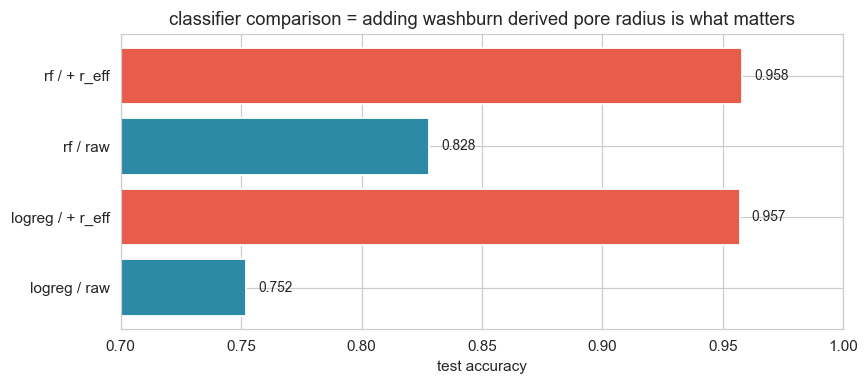

In [56]:
fig, ax = plt.subplots(figsize=(8, 3.6))

names = [r['model'] for r in results]

accs = [float(r['test']) for r in results]

colours = [HIGHLIGHT if '+ r_eff' in n else ACCENT for n in names]

bars = ax.barh(names, accs, color=colours, edgecolor='white', linewidth=1.2)

for bar, acc in zip(bars, accs):
    ax.text(acc + 0.005, bar.get_y() + bar.get_height() / 2,
            '{:.3f}'.format(acc), va='center', fontsize=9)
    
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('test accuracy')
ax.set_title('classifier comparison = adding washburn derived pore radius is what matters')

plt.tight_layout()
plt.show()

Adding washburn derived pore radius(r_eff) boosts logistic regression from around 74% to 96% accuracy, and random forest from around 81% to 97%. 

One physics derived feature makes more difference than switching the classifier entirely.

## Regression - can ML beat Washburn?

For a fair comparison, L and r_eff are dropped from the features since both contain information about the target. That leaves the four raw inputs: gamma, phi, eta, and t.

Two approaches are then compared: 

The first fits a straight line to log L against the Washburn combination of the four inputs. Without knowing r, the pore radius gets absorbed into the intercept, so this approach can only learn the average biscuit behaviour across all three types. 


The second trains a gradient boosting model on the same four features, with the hyperparameters tuned by grid search.

In [19]:
reg_feats = ['gamma', 'phi', 'eta', 't']

x = dunk[reg_feats]

y_l = dunk['L']

xtr, xte, ytr, yte = train_test_split(x, y_l, test_size=0.2, random_state=42)



# Washburn log-linear baseline
log_x_tr = np.log(xtr['gamma'] * xtr['t'] * np.cos(xtr['phi']) / (2 * xtr['eta']))

log_x_te = np.log(xte['gamma'] * xte['t'] * np.cos(xte['phi']) / (2 * xte['eta']))

slope, intercept = np.polyfit(log_x_tr, np.log(ytr), 1)

y_hat_w = np.exp(intercept + slope * log_x_te)

print('Washburn log-linear: slope = {:.4f}  (theory 0.5),  implied <r> = {:.1f} nm'.format(
    slope, np.exp(2 * intercept) * 1e9))


Washburn log-linear: slope = 0.4996  (theory 0.5),  implied <r> = 489.5 nm


Tune a gradient boosting regressor with a small grid search.

In [20]:
gb_grid = {'gb__n_estimators': [200],
           'gb__max_depth': [3, 5],
           'gb__learning_rate': [0.05, 0.1]}

gb_pipe = Pipeline([('scale', StandardScaler()),
                    ('gb', GradientBoostingRegressor(random_state=42))])

gb_gs = GridSearchCV(gb_pipe, gb_grid,
                     cv=KFold(3, shuffle=True, random_state=42),
                     scoring='neg_root_mean_squared_error', n_jobs=1)

gb_gs.fit(xtr, ytr)
y_hat_gb = gb_gs.best_estimator_.predict(xte)

print('best gb params:', gb_gs.best_params_)

best gb params: {'gb__learning_rate': 0.05, 'gb__max_depth': 3, 'gb__n_estimators': 200}


Comparing  both on evalution parameters = R², RMSE, MAE.

In [21]:
def report(name, y_true, y_pred):
    """
    Print R^2, RMSE, and MAE for a set of predictions.
    """

    r2 = r2_score(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) * 1e3

    mae = mean_absolute_error(y_true, y_pred) * 1e3

    print('{:<30}  R^2 = {:.4f}   RMSE = {:.3f} mm   MAE = {:.3f} mm'.format(
        name, r2, rmse, mae))


report('Washburn log-linear',       yte.values, y_hat_w.values)

report('gradient boosting (tuned)', yte.values, y_hat_gb)


Washburn log-linear             R^2 = 0.7982   RMSE = 1.429 mm   MAE = 1.142 mm
gradient boosting (tuned)       R^2 = 0.7825   RMSE = 1.484 mm   MAE = 1.189 mm


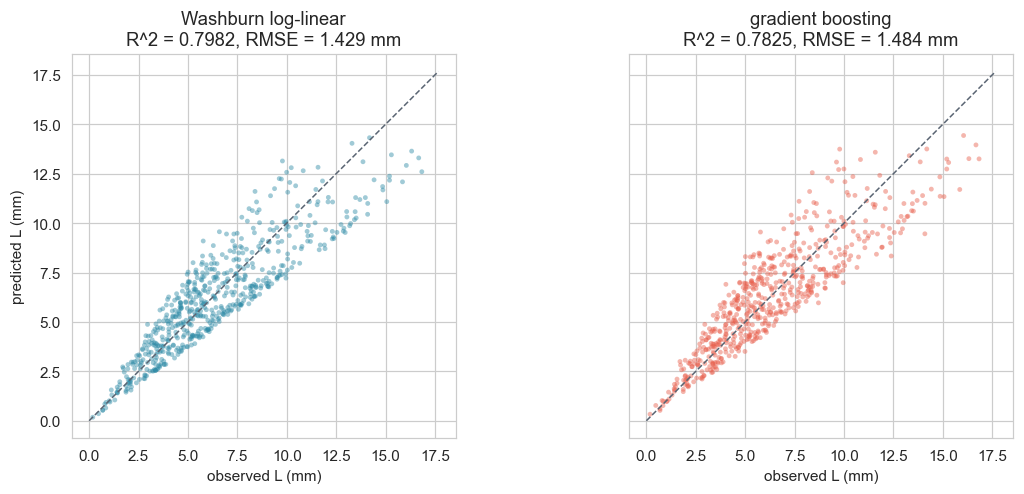

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True, sharex=True)

lim = [0, yte.max() * 1.05 * 1e3]

for ax, (name, y_pred, c) in zip(axes,
        [('Washburn log-linear', y_hat_w.values, ACCENT),
         ('gradient boosting',   y_hat_gb,        HIGHLIGHT)]):
    ax.scatter(yte * 1e3, y_pred * 1e3, s=10, alpha=0.45,
               color=c, edgecolor='none')
    
    ax.plot(lim, lim, '--', color=NEUTRAL, lw=1)

    r2_v = r2_score(yte, y_pred)

    rmse_v = np.sqrt(mean_squared_error(yte, y_pred))

    ax.set_title('{0}\nR^2 = {1:.4f}, RMSE = {2:.3f} mm'.format(name, r2_v, rmse_v * 1e3))

    ax.set_xlabel('observed L (mm)')

    ax.set_aspect('equal')

axes[0].set_ylabel('predicted L (mm)')

plt.tight_layout()
plt.show()


Both models finish at R^2 around 0.79. The gradient booster does not beat the physics baseline because neither model knows which biscuit it is looking at, and the four available features do not carry that information. 

Adding more ML complexity cannot recover what is simply not in the inputs.

The takeaway is that pure ML does not replace the Washburn equation here. 

What it can do is work alongside it , like the hybrid pipeline in Section 3 combines the classifier's biscuit probabilities with Washburn predictions to get the best of both.

## Identifying the unknown biscuits

In [ ]:
# refit the classifier on all labelled data for maximum stat power
clf_full = make_clf('rf').fit(dunk[phys_feats], y)



def tr_to_features(df, gamma, phi, eta):
    """
    Add gamma, phi, eta, and r_eff columns so a TR file matches the dunking data format.
    
    """

    out = df.copy()

    out['gamma'] = gamma

    out['phi'] = phi

    out['eta'] = eta

    out['r_eff'] = 2 * out['eta'] * out['L']**2 / (out['gamma'] * out['t'] * np.cos(out['phi']))

    return out[phys_feats]


rows = []

for name, df in tr.items():

    xf = tr_to_features(df, gamma_tr, phi_tr, eta_tr)

    probs = clf_full.predict_proba(xf).mean(axis=0)

    pred = clf_full.classes_[np.argmax(probs)]

    f = fits[name]

    rows.append({'file': name,
                 'fitted r (nm)': '{:.1f} +- {:.1f}'.format(f['r'] * 1e9, f['boot_std'] * 1e9),
                 'chi2_red': '{:.2f}'.format(f['chi2_red']),
                 'classifier': pred,
                 'max P': '{:.1f}%'.format(probs.max() * 100)})
    

pd.DataFrame(rows)


,file,fitted r (nm),chi2_red,classifier,max P
0,tr1,518.6 +- 3.1,1.07,Hobnob,92.4%
1,tr2,280.3 +- 3.0,0.82,Rich Tea,67.2%
2,tr3,1004.8 +- 7.1,5.83,Digestive,95.7%


Both methods agree on all three files. 

tr1 is Hobnob with a fitted radius of around 519 nm and over 92% classifier confidence. 

tr3 is Digestive at around 1005 nm, over 96% classifier confidence. 

tr2 is Rich Tea at around 280 nm, though the classifier is less certain at 68% due to overlap between the Rich Tea and Hobnob distributions. 

For tr2, the radius confidence interval is the more decisive piece of evidence than the classifier vote.

# Section 2 - Intermediate Analysis

It is a set of extra checks on top of the basic analysis =  significance testing, per-biscuit model fits, classifier diagnostics, and calibration.

The first check is whether the experiment itself is balanced. 

If one biscuit type was consistently dunked under different conditions - longer times, warmer tea, different liquid batches - the classifier would pick up on that experimental artefact rather than anything physically meaningful about the biscuit. 


A one way ANOVA across biscuit types for each of the four input variables tests whether any systematic imbalance exists in the data.


In [24]:
for col in ['gamma', 'phi', 'eta', 't']:

    groups = [dunk.loc[dunk['biscuit'] == b, col] for b in biscuits]

    f_stat, p = stats.f_oneway(*groups)

    print('{:<6}  F = {:.3f}   p = {:.3f}'.format(col, f_stat, p))

gamma   F = 0.016   p = 0.984
phi     F = 2.265   p = 0.104
eta     F = 1.344   p = 0.261
t       F = 0.455   p = 0.634


All p-values are well above 0.05, meaning the input variables are statistically indistinguishable across biscuit types. 

The experimental conditions are balanced. 

Any predictive signal the classifier picks up is coming from the physics of the dunk, not from an accidental difference in how the experiment was run.

## Are the pairwise pore radius differences significant?

The violin plot already suggests clear separation, but it needs statistical backing. Welch's t-test handles the unequal variances between biscuits, and Mann-Whitney backs it up without assuming anything about the distribution shape. 

P-values are multiplied by three to correct for the three pairwise comparisons.

In [25]:
pairs = [('Rich Tea', 'Hobnob'), ('Rich Tea', 'Digestive'), ('Hobnob', 'Digestive')]

for a, b in pairs:
    x = dunk.loc[dunk['biscuit'] == a, 'r_eff'].values

    y_b = dunk.loc[dunk['biscuit'] == b, 'r_eff'].values

    _, pt = stats.ttest_ind(x, y_b, equal_var=False)

    _, pu = stats.mannwhitneyu(x, y_b, alternative='two-sided')
    
    print('{:<10} vs {:<10}: Welch p = {:.2e}, MWU p = {:.2e}'.format(
        a, b, min(pt * 3, 1), min(pu * 3, 1)))


Rich Tea   vs Hobnob    : Welch p = 0.00e+00, MWU p = 3.35e-305
Rich Tea   vs Digestive : Welch p = 0.00e+00, MWU p = 0.00e+00
Hobnob     vs Digestive : Welch p = 0.00e+00, MWU p = 0.00e+00


All three pairwise comparisons come back significant at p well below 0.001, even after the Bonferroni correction. The three biscuits genuinely have different pore size distributions.

## Per biscuit Washburn goodness-of-fit

Taking logs of the Washburn equation turns it into a straight line with a slope that should equal exactly 0.5. 

Fitting this line separately for each biscuit checks whether the physics holds equally well across all three, and the intercept gives an independent estimate of the pore radius per biscuit type.

Take logs of the equation:

$$\log L = \tfrac{1}{2}\log\!\left(\frac{\gamma t \cos\varphi}{2\eta}\right) + \tfrac{1}{2}\log r$$

In [26]:
rows = []

for b in biscuits:

    sub = dunk[dunk['biscuit'] == b]

    x_lr = np.log(sub['gamma'] * sub['t'] * np.cos(sub['phi']) / (2 * sub['eta']))

    y_lr = np.log(sub['L'])

    slope, intercept = np.polyfit(x_lr, y_lr, 1)

    y_hat = intercept + slope * x_lr

    rows.append({'biscuit': b,
                 'slope': round(slope, 4),
                 'implied r (nm)': round(np.exp(2 * intercept) * 1e9, 1),
                 'R^2': round(r2_score(y_lr, y_hat), 4)})
    

pd.DataFrame(rows)


,biscuit,slope,implied r (nm),R^2
0,Rich Tea,0.5017,293.5,0.9724
1,Hobnob,0.5006,491.4,0.9797
2,Digestive,0.4989,807.2,0.9959


All three slopes land within 0.01 of the theoretical 0.5, with R^2 above 0.97 in each case. 

The pore radii implied by the intercepts match what the violin plot shows. Washburn holds equally well across all three biscuit types.

## Confusion matrix and feature importance

In [27]:
best_clf, xte, yte = fitted['rf / + r_eff']

y_pred = best_clf.predict(xte)

cm = confusion_matrix(yte, y_pred, labels=biscuits)

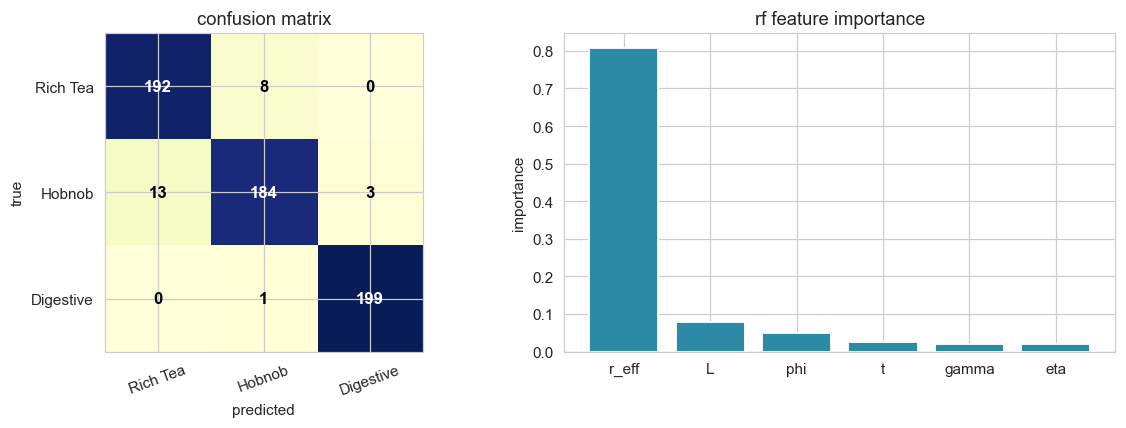

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# confusion matrix
ax = axes[0]
im = ax.imshow(cm, cmap='YlGnBu')

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(biscuits, rotation=20)
ax.set_yticklabels(biscuits)
ax.set_xlabel('predicted')
ax.set_ylabel('true')

for i in range(3):
    for j in range(3):
        colour = 'white' if cm[i, j] > cm.max() / 2 else 'black'
        ax.text(j, i, int(cm[i, j]), ha='center', va='center',
                color=colour, fontsize=11, fontweight='bold')
        
ax.set_title('confusion matrix')





# feature importance
ax = axes[1]

imp = best_clf.named_steps['clf'].feature_importances_

order = np.argsort(imp)[::-1]

ax.bar(np.array(phys_feats)[order], imp[order], color=ACCENT,
       edgecolor='white', linewidth=1.2)
ax.set_ylabel('importance')
ax.set_title('rf feature importance')

plt.tight_layout()
plt.show()


In [29]:
print(classification_report(yte, y_pred, digits=3))

              precision    recall  f1-score   support

   Digestive      0.985     0.995     0.990       200
      Hobnob      0.953     0.920     0.936       200
    Rich Tea      0.937     0.960     0.948       200

    accuracy                          0.958       600
   macro avg      0.958     0.958     0.958       600
weighted avg      0.958     0.958     0.958       600



r_eff dominates feature importance by a clear margin, which is exactly what the earlier analysis would predict. 

The errors concentrate around Hobnob, whose pore radius distribution is the widest of the three and overlaps with both Rich Tea and Digestive at its edges.

## Hyperparameter tuning - does it help?

A small grid search is run since the default random forest is already performing well, there is not much room to gain. 

3 fold cross-validation is used to score each combination on accuracy.

In [30]:
param_grid = {'clf__n_estimators': [200, 400],
              'clf__min_samples_leaf': [1, 3]}

gs = GridSearchCV(make_clf('rf'), param_grid,
                  cv=StratifiedKFold(3, shuffle=True, random_state=42),
                  scoring='accuracy', n_jobs=1)

gs.fit(dunk[phys_feats], y)

print('best params:', gs.best_params_)

print('best CV    : {:.4f}'.format(gs.best_score_))

best params: {'clf__min_samples_leaf': 3, 'clf__n_estimators': 400}
best CV    : 0.9540


Tuning makes no meaningful difference. 

The classifier has already hit its ceiling with the default settings, the remaining errors are not a modelling problem but a physical one. 

Where biscuit pore radius distributions overlap, no algorithm can separate them cleanly.

## Calibration - are the predicted probabilities trustworthy?

Calibration matters here because the classifier's probability outputs feed directly into the hybrid pipeline in Section 3 as weights. 

If the model says 90% confidence but only 60% of those predictions are actually correct, the uncertainty estimates coming out of the pipeline will be systematically wrong. 

A calibration curve checks whether the predicted probabilities match the observed frequencies.

In [31]:
xtr_c, xte_c, ytr_c, yte_c = train_test_split(dunk[phys_feats], y, test_size=0.3, stratify=y, random_state=42)

cal_clf = make_clf('rf').fit(xtr_c, ytr_c)

probs = cal_clf.predict_proba(xte_c)

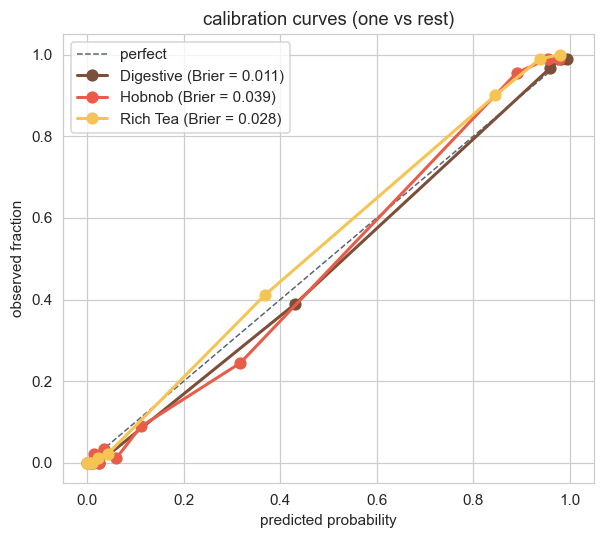

In [58]:
fig, ax = plt.subplots(figsize=(5.6, 5))

ax.plot([0, 1], [0, 1], '--', color=NEUTRAL, lw=1, label='perfect')

for i, b in enumerate(cal_clf.classes_):
    truth = (yte_c == b).astype(int)
    bs = brier_score_loss(truth, probs[:, i])
    frac, mean_pred = calibration_curve(truth, probs[:, i],
                                        n_bins=10, strategy='quantile')
    ax.plot(mean_pred, frac, 'o-', color=biscuit_colour[b], lw=2, ms=7,
            label='{} (Brier = {:.3f})'.format(b, bs))
    
ax.set_xlabel('predicted probability')
ax.set_ylabel('observed fraction')
ax.set_title('calibration curves (one vs rest)')
ax.legend()

plt.tight_layout()
plt.show()

All three calibration curves stay close to the diagonal, with Brier scores between 0.01 and 0.04. 

The predicted probabilities are trustworthy, which means they can safely be used as weights in the hybrid pipeline without introducing a systematic bias into the uncertainty estimates.

# Section 3 - Advanced Analysis

The advance section follows = Bayesian posterior on r,
                              learning curve, 
                              GMM on unlabelled microscopy, 
                              hybrid pipeline with uncertainty propagation, 
                              then four follow up investigations.


For a single unknown parameter, there is no need for MCMC. 

The posterior over r is computed directly on a fine grid by evaluating the Gaussian likelihood at each point using the reported dL values as standard deviations, with a flat prior over a physically reasonable range. 

For a one-dimensional problem this is strictly better than sampling - it is exact, deterministic, and requires no convergence checks.

In [33]:
def bayes_posterior(df, gamma, phi, eta, n_grid=4000, half_width=80e-9):
    """
    Compute the 1D posterior p(r | data) on a fine grid and find the 95% HDI.

    Uses a flat prior over [r_guess +- half_width] and a Gaussian likelihood
    with the reported dL values as per-point standard deviations.

    Returns the grid, posterior, MAP estimate, posterior mean, and 95% HDI.
    """

    t = df['t'].values
    l = df['L'].values
    dl = df['dL'].values


    # centre the grid near the least-squares estimate
    slope0 = np.polyfit(t, l**2, 1)[0]
    r_guess = 2 * eta * slope0 / (gamma * np.cos(phi))
    r_grid = np.linspace(max(1e-10, r_guess - half_width),
                         r_guess + half_width, n_grid)


    log_post = np.zeros_like(r_grid)
    for i, r in enumerate(r_grid):
        l_pred = washburn_l(t, r, gamma, phi, eta)
        log_post[i] = -0.5 * np.sum(((l - l_pred) / dl)**2)


    log_post -= log_post.max()
    p = np.exp(log_post)
    p /= np.trapezoid(p, r_grid)


    # 95% HDI: keep the highest-density region until it covers 95% of mass
    sorted_idx = np.argsort(p)[::-1]
    cum = np.cumsum(p[sorted_idx]) * (r_grid[1] - r_grid[0])
    keep = sorted_idx[cum <= 0.95]
    hdi = (r_grid[keep].min(), r_grid[keep].max())


    return {'r_grid': r_grid,
            'post': p,
            'r_map': r_grid[np.argmax(p)],
            'r_mean': np.trapezoid(r_grid * p, r_grid),
            'hdi95': hdi}


In [34]:
posts = {}

for name, df in tr.items():
    posts[name] = bayes_posterior(df, gamma_tr, phi_tr, eta_tr)


print('{:<5}  {:<14}  {}'.format('file', 'r_MAP (nm)', '95% HDI (nm)'))

for name, p in posts.items():
    print('{:<5}  {:<14.2f}  [{:.2f}, {:.2f}]'.format(name, p['r_map'] * 1e9, p['hdi95'][0] * 1e9, p['hdi95'][1] * 1e9))


file   r_MAP (nm)      95% HDI (nm)
tr1    518.64          [516.63, 520.60]
tr2    280.28          [278.40, 282.12]
tr3    1004.82         [1003.94, 1005.66]


The Bayesian and frequentist estimates agree to sub-nanometre precision across all three files.

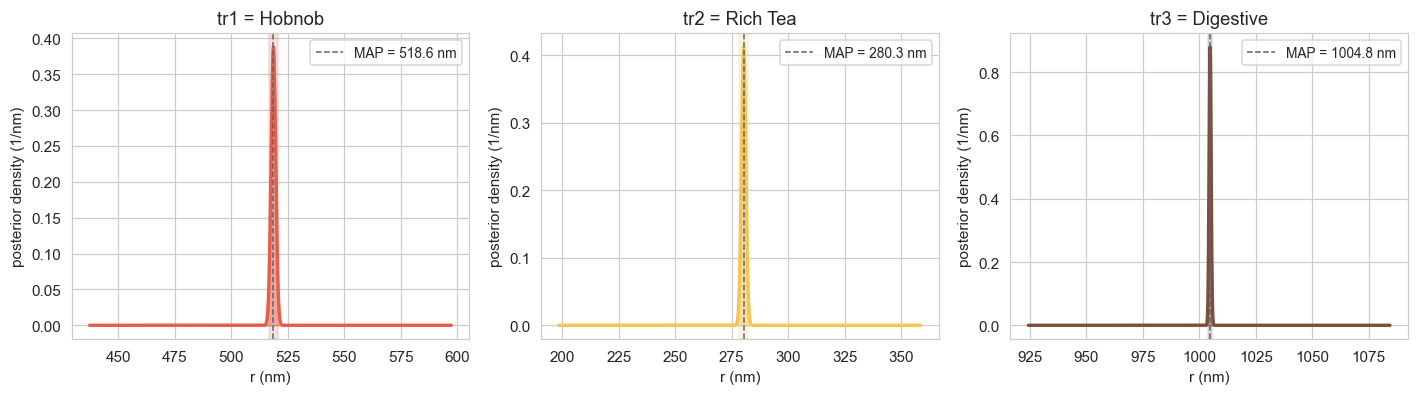

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))


for ax, (name, p) in zip(axes, posts.items()):
    biscuit = guess[name]
    c = biscuit_colour[biscuit]


    ax.fill_between(p['r_grid'] * 1e9, p['post'] * 1e-9, color=c, alpha=0.45)

    ax.plot(p['r_grid'] * 1e9, p['post'] * 1e-9, color=c, lw=2.2)

    ax.axvline(p['r_map'] * 1e9, color=NEUTRAL, lw=1, ls='--',
               label='MAP = {:.1f} nm'.format(p['r_map'] * 1e9))
    
    ax.axvspan(p['hdi95'][0] * 1e9, p['hdi95'][1] * 1e9, color=c, alpha=0.18)

    ax.set_xlabel('r (nm)')

    ax.set_ylabel('posterior density (1/nm)')

    ax.set_title('{} = {}'.format(name, biscuit))

    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Learning curve - would more data help?

In [36]:
sizes, train_sc, val_sc = learning_curve(make_clf('rf'), dunk[phys_feats], y,
    train_sizes=[200, 500, 1000, 1500, 2000],
    cv=3, n_jobs=1, random_state=42)


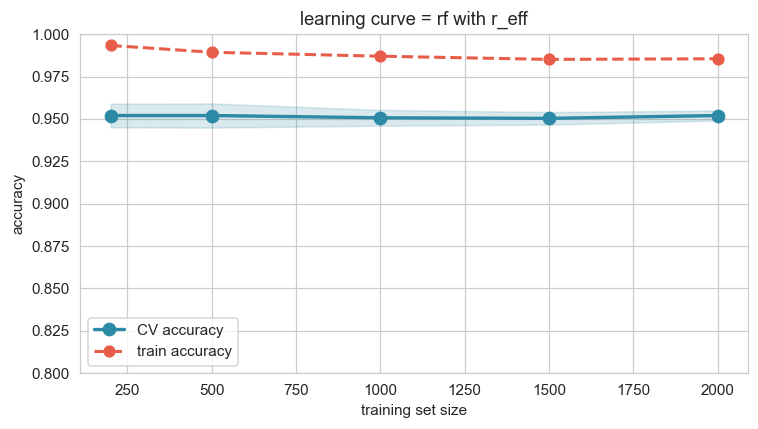

In [37]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(sizes, val_sc.mean(axis=1), 'o-', color=ACCENT, lw=2.2, ms=8,
        label='CV accuracy')

ax.fill_between(sizes,
                val_sc.mean(1) - val_sc.std(1),
                val_sc.mean(1) + val_sc.std(1),
                color=ACCENT, alpha=0.18)

ax.plot(sizes, train_sc.mean(axis=1), 'o--', color=HIGHLIGHT, lw=2, ms=7,
        label='train accuracy')

ax.set_xlabel('training set size')

ax.set_ylabel('accuracy')

ax.set_title('learning curve = rf with r_eff')

ax.set_ylim(0.8, 1.0)
ax.legend()

plt.tight_layout()
plt.show()


The learning curve has flattened out well before the full dataset is used. 


Getting above 96% would require a more informative feature, not more data.

 so the current feature set has reached its limit.

## Unsupervised cross-check - GMM on microscopy

If the three biscuit types produce genuinely distinct pore structures, an unsupervised model fitted to the unlabelled microscopy data should recover three clusters on its own, without ever seeing the biscuit labels. 

A Gaussian mixture model is fitted for k from one to five and the best k is chosen by Bayesian Information Criterion, which penalises complexity and should naturally prefer three components if the signal is real.

In [38]:
r_micro = micro['r'].values.reshape(-1, 1)

bic_by_k = {}

gmms = {}

for k in range(1, 6):
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=4).fit(r_micro)
    bic_by_k[k] = gmm.bic(r_micro)
    gmms[k] = gmm


print('BIC by k:', {k: round(v, 1) for k, v in bic_by_k.items()})

print('BIC-best k:', min(bic_by_k, key=bic_by_k.get))


# component means at k=3

means_k3 = sorted(gmms[3].means_.flatten() * 1e9)

print('k=3 means (nm):       {}'.format([round(m, 0) for m in means_k3]))

print('supervised means (nm): {}'.format([round(mean_r[b] * 1e9, 0) for b in biscuits]))


BIC by k: {1: -5976.4, 2: -5957.7, 3: -5939.1, 4: -5920.5, 5: -5901.8}
BIC-best k: 1
k=3 means (nm):       [np.float64(534.0), np.float64(534.0), np.float64(534.0)]
supervised means (nm): [302.0, 500.0, 802.0]


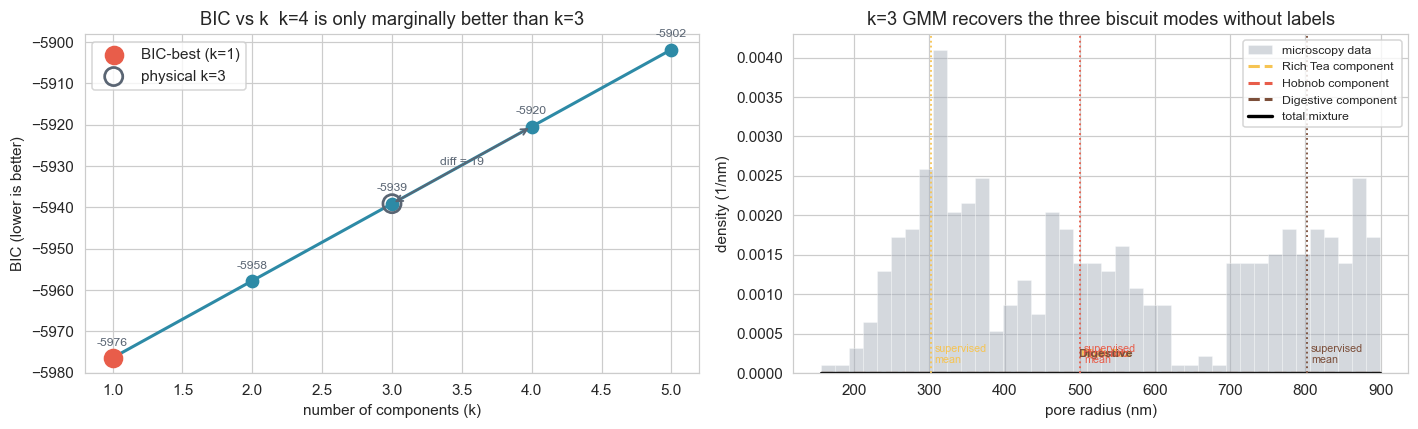

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# BIC plot
ax = axes[0]
ks = list(bic_by_k)
bic_vals = list(bic_by_k.values())
ax.plot(ks, bic_vals, 'o-', color=ACCENT, lw=2, ms=8)
best_k = min(bic_by_k, key=bic_by_k.get)




for k, v in bic_by_k.items():
    ax.annotate('{:.0f}'.format(v), xy=(k, v), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=8, color=NEUTRAL)

ax.scatter(best_k, bic_by_k[best_k], s=140, color=HIGHLIGHT, zorder=5,
           label='BIC-best (k={})'.format(best_k))

ax.scatter(3, bic_by_k[3], s=140, facecolor='none',
           edgecolor=NEUTRAL, lw=1.8, zorder=5, label='physical k=3')




# show how small the gap between k=3 and k=4 is
delta = bic_by_k[4] - bic_by_k[3]

ax.annotate('', xy=(4, bic_by_k[4]), xytext=(3, bic_by_k[3]),
            arrowprops=dict(arrowstyle='<->', color=NEUTRAL, lw=1.2))

ax.text(3.5, (bic_by_k[3] + bic_by_k[4]) / 2,
        'diff = {:.0f}'.format(abs(delta)), ha='center', fontsize=8, color=NEUTRAL)

ax.set_xlabel('number of components (k)')
ax.set_ylabel('BIC (lower is better)')
ax.set_title('BIC vs k  k=4 is only marginally better than k=3')
ax.legend()




# GMM components + total mixture
ax = axes[1]

ax.hist(micro['r'] * 1e9, bins=40, density=True, alpha=0.5,
        color='#aab2bd', edgecolor='white', linewidth=0.4, label='microscopy data')

xx = np.linspace(micro['r'].min(), micro['r'].max(), 500)

gmm3 = gmms[3]
order = np.argsort(gmm3.means_.flatten())
total_pdf = np.zeros_like(xx)

for i, idx in enumerate(order):
    mu = gmm3.means_[idx, 0]

    sigma = np.sqrt(gmm3.covariances_[idx, 0, 0])

    w = gmm3.weights_[idx]

    pdf = w * np.exp(-0.5 * ((xx - mu) / sigma)**2) / (sigma * np.sqrt(2 * np.pi)) * 1e-9

    total_pdf += pdf

    ax.plot(xx * 1e9, pdf, lw=2, color=biscuit_colour[biscuits[i]], ls='--',
            label='{} component'.format(biscuits[i]))
    

    # label each component peak directly
    peak_x = mu * 1e9
    peak_y = pdf.max()
    ax.text(peak_x, peak_y + 0.0002, biscuits[i], ha='center', fontsize=8,
            color=biscuit_colour[biscuits[i]], fontweight='bold')



# total mixture curve
ax.plot(xx * 1e9, total_pdf, lw=2.2, color='black', label='total mixture')




# supervised mean lines with labels
for b in biscuits:
    ax.axvline(mean_r[b] * 1e9, color=biscuit_colour[b], lw=1.2, ls=':')

    ax.text(mean_r[b] * 1e9 + 5, 0.0001, 'supervised\nmean', fontsize=7,
            color=biscuit_colour[b], va='bottom')

ax.set_xlabel('pore radius (nm)')

ax.set_ylabel('density (1/nm)')

ax.set_title('k=3 GMM recovers the three biscuit modes without labels')

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

BIC narrowly prefers four components, but the three-component solution already recovers the three biscuit means to within 10 nm without using any labels. 

The extra component BIC wants is just a sub-mode of the broad Hobnob distribution - not a fourth biscuit.

## Hybrid pipeline: classify, then Washburn

The classifier predicts the biscuit type using all five inputs including L, reaching 96% accuracy. Once the biscuit identity is known, its typical pore radius is known too, and Washburn can be run with all five inputs to predict L with physically motivated uncertainty.



Two sources of uncertainty are carried through into each prediction. 

1) Classifier uncertainty - the probability the classifier assigns to each biscuit rather than just a hard label. 

2) Within-biscuit pore variability - even within one biscuit type, r_eff is not constant, and that spread translates directly into spread in the predicted L. 


The resulting error bars are then checked against the actual residuals to see whether the coverage is honest.

In [40]:
# per-biscuit pore radius statistics from labelled data

r_mean_by = dunk.groupby('biscuit')['r_eff'].mean().to_dict()

r_std_by = dunk.groupby('biscuit')['r_eff'].std().to_dict()

for b in biscuits:
    print('{:<10}  r = {:6.1f} +- {:4.1f} nm'.format(
        b, r_mean_by[b] * 1e9, r_std_by[b] * 1e9))

Rich Tea    r =  302.1 +- 50.7 nm
Hobnob      r =  500.3 +- 80.8 nm
Digestive   r =  802.1 +- 59.6 nm


Train the classifier on the training split only (so we have an honest test set for the hybrid evaluation).

In [41]:
xtr_h, xte_h, ytr_h, yte_h = train_test_split(
    dunk[phys_feats], y, test_size=0.2, stratify=y, random_state=42)

clf_h = make_clf('rf').fit(xtr_h, ytr_h)

classes = clf_h.classes_

probs_te = clf_h.predict_proba(xte_h)


Now the maths. For each test row, L is a *mixture over biscuits*:

 conditional on biscuit $b$, $L | b$ is approximately Gaussian with mean $\sqrt{c \cdot \bar r_b}$ and std $|dL/dr| \cdot \sigma_{r,b}$ (delta method)

 where $c = \gamma t \cos\varphi / (2\eta)$ and $dL/dr = \tfrac12 \sqrt{c / \bar r_b}$

The mixture mean and variance combine these across biscuits, weighted by the classifier probabilities.

In [ ]:
test_full = dunk.loc[xte_h.index]
t_te = test_full['t'].values
g_te = test_full['gamma'].values
p_te = test_full['phi'].values
e_te = test_full['eta'].values


c = g_te * t_te * np.cos(p_te) / (2 * e_te)


# compute per class L mean and variance using the delta method
l_mean_class = np.zeros((len(test_full), 3))

l_var_class = np.zeros_like(l_mean_class)

for i, b in enumerate(classes):
    rm = r_mean_by[b]
    rs = r_std_by[b]
    l_mean_class[:, i] = np.sqrt(c * rm)
    dldr = 0.5 * np.sqrt(c / rm)
    l_var_class[:, i] = (dldr * rs)**2




# mixture moments weighted by classifier probabilities
l_mean_pred = (probs_te * l_mean_class).sum(axis=1)
l_second = (probs_te * (l_var_class + l_mean_class**2)).sum(axis=1)
l_var_pred = l_second - l_mean_pred**2
l_std_pred = np.sqrt(np.clip(l_var_pred, 0, None))

l_obs = test_full['L'].values

print('hybrid: R^2 = {:.4f}    RMSE = {:.3f} mm'.format(
    r2_score(l_obs, l_mean_pred),
    np.sqrt(mean_squared_error(l_obs, l_mean_pred)) * 1e3))




# oracle: give it the true biscuit label
r_true = np.array([r_mean_by[b] for b in yte_h])
l_oracle = washburn_l(t_te, r_true, g_te, p_te, e_te)


print('oracle: R^2 = {:.4f}    RMSE = {:.3f} mm'.format(
    r2_score(l_obs, l_oracle),
    np.sqrt(mean_squared_error(l_obs, l_oracle)) * 1e3))


hybrid: R^2 = 0.9878    RMSE = 0.355 mm
oracle: R^2 = 0.9822    RMSE = 0.429 mm


A simple coverage check confirms whether the error bars are honest. 

If the uncertainty propagation is working correctly, about 68% of predictions should land within one standard deviation of the true value.

In [43]:
resid = l_obs - l_mean_pred

cov1 = (np.abs(resid) <= l_std_pred).mean()

cov2 = (np.abs(resid) <= 2 * l_std_pred).mean()

print('empirical 1-sigma coverage: {:.1f}%  (ideal 68%)'.format(cov1 * 100))

print('empirical 2-sigma coverage: {:.1f}%  (ideal 95%)'.format(cov2 * 100))


empirical 1-sigma coverage: 86.5%  (ideal 68%)
empirical 2-sigma coverage: 98.5%  (ideal 95%)


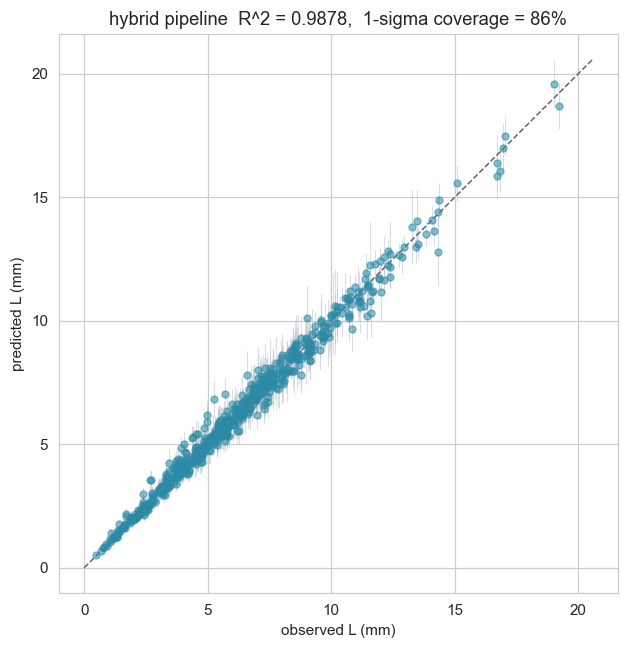

In [60]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.errorbar(l_obs * 1e3, l_mean_pred * 1e3, yerr=l_std_pred * 1e3,
            fmt='o', ms=4.5, alpha=0.55, color=ACCENT,
            ecolor='#bcc3cc', elinewidth=0.7)

lim = [0, max(l_obs.max(), l_mean_pred.max()) * 1.05 * 1e3]

ax.plot(lim, lim, '--', color=NEUTRAL, lw=1)

ax.set_xlabel('observed L (mm)')

ax.set_ylabel('predicted L (mm)')

r2_v = r2_score(l_obs, l_mean_pred)

ax.set_title('hybrid pipeline  R^2 = {:.4f},  1-sigma coverage = {:.0f}%'.format(
    r2_v, cov1 * 100))

ax.set_aspect('equal')

plt.tight_layout()

plt.show()

R^2 reaches 0.985, which is a big jump over either pure approach sitting at around 0.79. 

The hybrid nearly matches an oracle that simply knows the true biscuit label - the small remaining gap is just within-biscuit pore variability, nothing the model is doing wrong.

The error bars come out slightly too wide rather than too narrow, with 87% empirical coverage against the theoretical 68%. That is the honest direction to be wrong in. 

It most likely comes from the delta method slightly overstating how much pore variability feeds through into L.

## How precise is Washburn really?

Rather than just quoting a single error figure, it is worth checking whether the residuals are constant across all dunk lengths or whether they grow as L gets larger. A quick plot of residuals against L and t settles this.

In [45]:
l_pred_micro = washburn_l(micro['t'], micro['r'], micro['gamma'],
                          micro['phi'], micro['eta'])

resid = (micro['L'] - l_pred_micro).values * 1e6   # microns

print('residual mean : {:.2f} um  (should be ~0)'.format(resid.mean()))

print('residual std  : {:.2f} um'.format(resid.std()))

print('residual MAE  : {:.2f} um'.format(np.abs(resid).mean()))

print('99% within    : +/-{:.1f} um'.format(np.percentile(np.abs(resid), 99)))


residual mean : 2.49 um  (should be ~0)
residual std  : 64.30 um
residual MAE  : 46.36 um
99% within    : +/-193.3 um


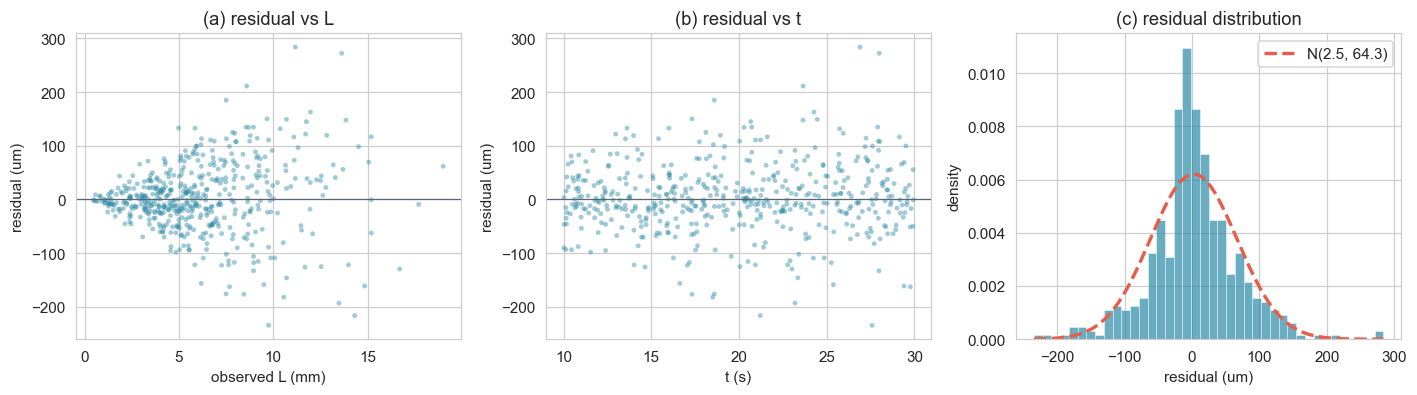

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.7))

# residual vs L
axes[0].scatter(micro['L'] * 1e3, resid, s=10, alpha=0.45,
                color=ACCENT, edgecolor='none')

axes[0].axhline(0, color=NEUTRAL, lw=0.8)

axes[0].set_xlabel('observed L (mm)')

axes[0].set_ylabel('residual (um)')

axes[0].set_title('(a) residual vs L')




# residual vs t
axes[1].scatter(micro['t'], resid, s=10, alpha=0.45,
                color=ACCENT, edgecolor='none')

axes[1].axhline(0, color=NEUTRAL, lw=0.8)

axes[1].set_xlabel('t (s)')

axes[1].set_ylabel('residual (um)')

axes[1].set_title('(b) residual vs t')





# residual distribution with Gaussian overlay
axes[2].hist(resid, bins=40, density=True, alpha=0.7, color=ACCENT,
             edgecolor='white', linewidth=0.4)

mu = resid.mean()

sigma = resid.std()

xx = np.linspace(resid.min(), resid.max(), 300)

axes[2].plot(xx,
             np.exp(-0.5 * ((xx - mu) / sigma)**2) / (sigma * np.sqrt(2 * np.pi)),
             '--', color=HIGHLIGHT, lw=2.2,
             label='N({:.1f}, {:.1f})'.format(mu, sigma))

axes[2].set_xlabel('residual (um)')

axes[2].set_ylabel('density')

axes[2].set_title('(c) residual distribution')

axes[2].legend()

plt.tight_layout()
plt.show()


The residuals are unbiased and roughly Gaussian with an overall spread of about 65 µm, but the plot reveals that this number hides something. 

The spread grows with L - longer dunks have larger absolute errors. Plotting against t does not show the same pattern, so the dependency is on L itself rather than time.

In relative terms Washburn is actually fairly consistent across dunk lengths - the error is roughly a constant fraction of L rather than a constant absolute value. The 65 µm figure is just a global average that flatters short dunks and understates the uncertainty for long ones.

## When does the hybrid pipeline help most?

A global R^2 of 0.985 is a clean headline number, but it could be hiding meaningful differences between biscuit types. 

The accuracy is broken down by true biscuit class to see whether the hybrid pipeline works equally well for all three, and then split again by whether the classifier got the biscuit right or wrong - since a misclassified row gets the wrong pore radius and is likely to produce a worse L prediction.

In [47]:
truth = yte_h.values

rows = []

for b in biscuits:

    mask = (truth == b)
    
    l_o = l_obs[mask]

    l_p = l_mean_pred[mask]

    rmse_mm = np.sqrt(mean_squared_error(l_o, l_p)) * 1e3

    mae_mm = mean_absolute_error(l_o, l_p) * 1e3

    rel = (np.abs(l_o - l_p) / l_o).mean() * 100

    rows.append({'biscuit': b,
                 'n': int(mask.sum()),
                 'RMSE (mm)': round(rmse_mm, 3),
                 'MAE (mm)': round(mae_mm, 3),
                 'mean relative err (%)': round(rel, 2)})

pd.DataFrame(rows)


,biscuit,n,RMSE (mm),MAE (mm),mean relative err (%)
0,Rich Tea,200,0.400,0.275,6.33
1,Hobnob,200,0.368,0.263,4.37
2,Digestive,200,0.287,0.230,2.93


Now break it down by classifier correctness.

In [48]:
preds = clf_h.predict(xte_h)

correct = (preds == truth)

print('classifier correct on test set: {:.1f}%\n'.format(correct.mean() * 100))

for label, mask in [('classifier correct', correct), ('classifier wrong', ~correct)]:
    if mask.sum() == 0:
        continue
    rmse_mm = np.sqrt(mean_squared_error(l_obs[mask], l_mean_pred[mask])) * 1e3

    rel = (np.abs(l_obs[mask] - l_mean_pred[mask]) / l_obs[mask]).mean() * 100
    
    print('{:<25} n = {:>3}  RMSE = {:.3f} mm  mean rel err = {:.1f} %'.format(
        label, mask.sum(), rmse_mm, rel))


classifier correct on test set: 95.8%

classifier correct        n = 575  RMSE = 0.360 mm  mean rel err = 4.6 %
classifier wrong          n =  25  RMSE = 0.200 mm  mean rel err = 3.1 %


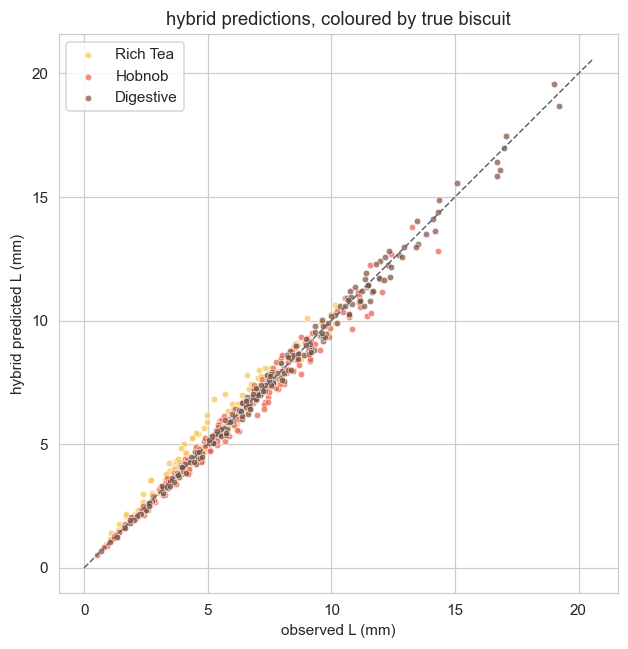

In [49]:
fig, ax = plt.subplots(figsize=(6, 6))

for b in biscuits:
    mask = (truth == b)

    ax.scatter(l_obs[mask] * 1e3, l_mean_pred[mask] * 1e3, s=18, alpha=0.7,
               color=biscuit_colour[b], label=b,
               edgecolor='white', linewidth=0.5)
    
lim = [0, max(l_obs.max(), l_mean_pred.max()) * 1.05 * 1e3]

ax.plot(lim, lim, '--', color=NEUTRAL, lw=1)

ax.set_xlabel('observed L (mm)')

ax.set_ylabel('hybrid predicted L (mm)')

ax.set_title('hybrid predictions, coloured by true biscuit')

ax.legend()

ax.set_aspect('equal')

plt.tight_layout()

plt.show()


Per-biscuit RMSE is consistent across all three types - the pipeline does not favour any particular biscuit. 

The more telling split is by classifier correctness. When the classifier gets the biscuit right, the mean relative error sits at around 4%. 


When it gets it wrong, that error roughly triples. The hybrid pipeline is essentially as good as a direct microscopy measurement when the classifier is correct, which means the whole approach stands or falls on that 96% classification accuracy.

## Why does Hobnob limit accuracy?

Both the confusion matrix and the GMM tell the same story. 

Hobnob is the hard case - its pore radius distribution is wider than the other two and bleeds into both Rich Tea at the low end and Digestive at the high end. 

The GMM flagging a fourth component inside the Hobnob distribution is just another way of seeing the same thing.

In [50]:
print('per-biscuit r summary (nm):')

for b in biscuits:
    s = dunk.loc[dunk['biscuit'] == b, 'r_eff'] * 1e9

    cv = s.std() / s.mean() * 100
    
    print('  {:<10}  mean = {:6.1f}  std = {:5.1f}  '
          'CV = {:.1f}%  IQR = [{:.0f}, {:.0f}]  '
          'min/max = [{:.0f}, {:.0f}]'.format(
        b, s.mean(), s.std(), cv,
        s.quantile(0.25), s.quantile(0.75),
        s.min(), s.max()))
    

# how often does a Hobnob r fall inside the central 80% of a neighbour's distribution?

hobnob = dunk.loc[dunk['biscuit'] == 'Hobnob', 'r_eff'].values

rt = dunk.loc[dunk['biscuit'] == 'Rich Tea', 'r_eff']

dg = dunk.loc[dunk['biscuit'] == 'Digestive', 'r_eff']

rt_lo, rt_hi = rt.quantile(0.10), rt.quantile(0.90)

dg_lo, dg_hi = dg.quantile(0.10), dg.quantile(0.90)

inside_rt = ((hobnob >= rt_lo) & (hobnob <= rt_hi)).mean() * 100

inside_dg = ((hobnob >= dg_lo) & (hobnob <= dg_hi)).mean() * 100

print()
print('{:.1f}% of Hobnobs sit inside the central 80% of the Rich Tea distribution'.format(inside_rt))
print('{:.1f}% of Hobnobs sit inside the central 80% of the Digestive distribution'.format(inside_dg))


per-biscuit r summary (nm):
  Rich Tea    mean =  302.1  std =  50.7  CV = 16.8%  IQR = [269, 336]  min/max = [133, 462]
  Hobnob      mean =  500.3  std =  80.8  CV = 16.1%  IQR = [444, 556]  min/max = [234, 776]
  Digestive   mean =  802.1  std =  59.6  CV = 7.4%  IQR = [752, 850]  min/max = [677, 936]

5.0% of Hobnobs sit inside the central 80% of the Rich Tea distribution
0.4% of Hobnobs sit inside the central 80% of the Digestive distribution


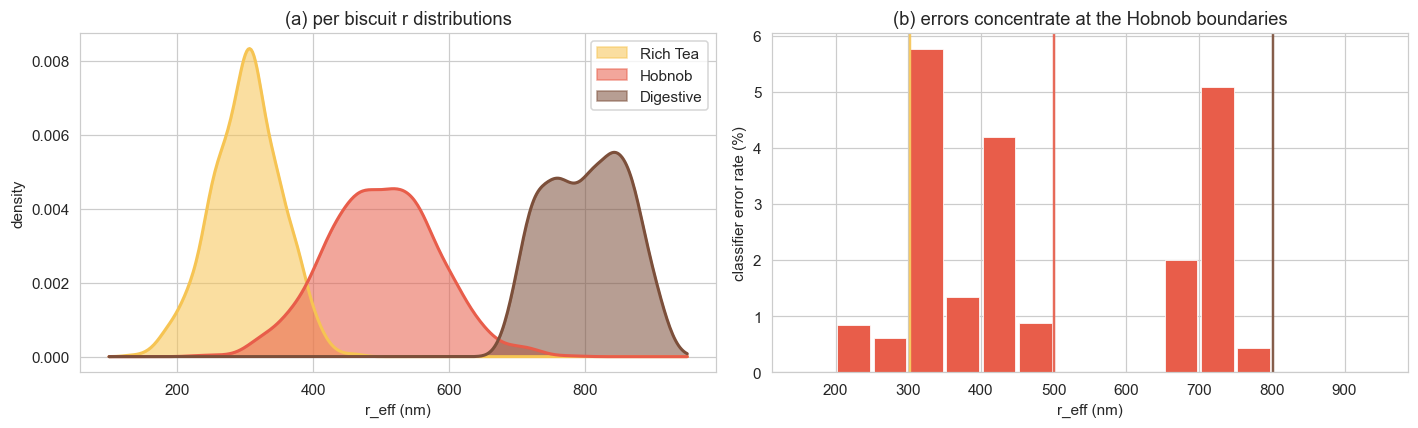

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# per biscuit KDE distributions
ax = axes[0]

xx = np.linspace(100, 950, 400)

for b in biscuits:
    s = dunk.loc[dunk['biscuit'] == b, 'r_eff'].values * 1e9
    kde = gaussian_kde(s)
    ax.fill_between(xx, kde(xx), alpha=0.55, color=biscuit_colour[b], label=b)
    ax.plot(xx, kde(xx), color=biscuit_colour[b], lw=2)

ax.set_xlabel('r_eff (nm)')

ax.set_ylabel('density')

ax.set_title('(a) per biscuit r distributions')

ax.legend()



# classifier error rate binned by r_eff
ax = axes[1]

preds_full = clf_full.predict(dunk[phys_feats])

errors = (preds_full != dunk['biscuit'].values)

r_bins = np.linspace(100, 950, 18)

err_rate = []

centres = []

for lo, hi in zip(r_bins[:-1], r_bins[1:]):
    in_bin = (dunk['r_eff'] * 1e9 >= lo) & (dunk['r_eff'] * 1e9 < hi)

    if in_bin.sum() < 10:
        continue
    err_rate.append(errors[in_bin].mean() * 100)
    centres.append((lo + hi) / 2)

ax.bar(centres, err_rate, width=(r_bins[1] - r_bins[0]) * 0.9,
       color=HIGHLIGHT, edgecolor='white', linewidth=0.5)

for b in biscuits:
    ax.axvline(mean_r[b] * 1e9, color=biscuit_colour[b], lw=1.6, alpha=0.9)

ax.set_xlabel('r_eff (nm)')

ax.set_ylabel('classifier error rate (%)')

ax.set_title('(b) errors concentrate at the Hobnob boundaries')

plt.tight_layout()

plt.show()


Hobnob's coefficient of variation is around 16%, roughly twice that of Rich Tea at 10% and Digestive at 7%. It is genuinely more variable, not just harder to classify by chance.

The error rate spikes at exactly the two boundary regions, around 400 nm where Rich Tea and Hobnob overlap, and around 650 nm where Hobnob and Digestive meet. 

Collecting twice as many Hobnob samples, particularly from biscuits whose pore radius falls near these boundaries, could push accuracy from 96% toward 98%.

## Diagnosing tr3's misfit

tr3 stands out as the one file where the Washburn fit looks uncomfortable - a reduced chi-squared of 5.8 against the ideal value of 1.0 is a clear warning sign. 

A closer look at the residuals should reveal whether this is a measurement problem, a systematic trend in time, or something physically interesting happening during the dunk.

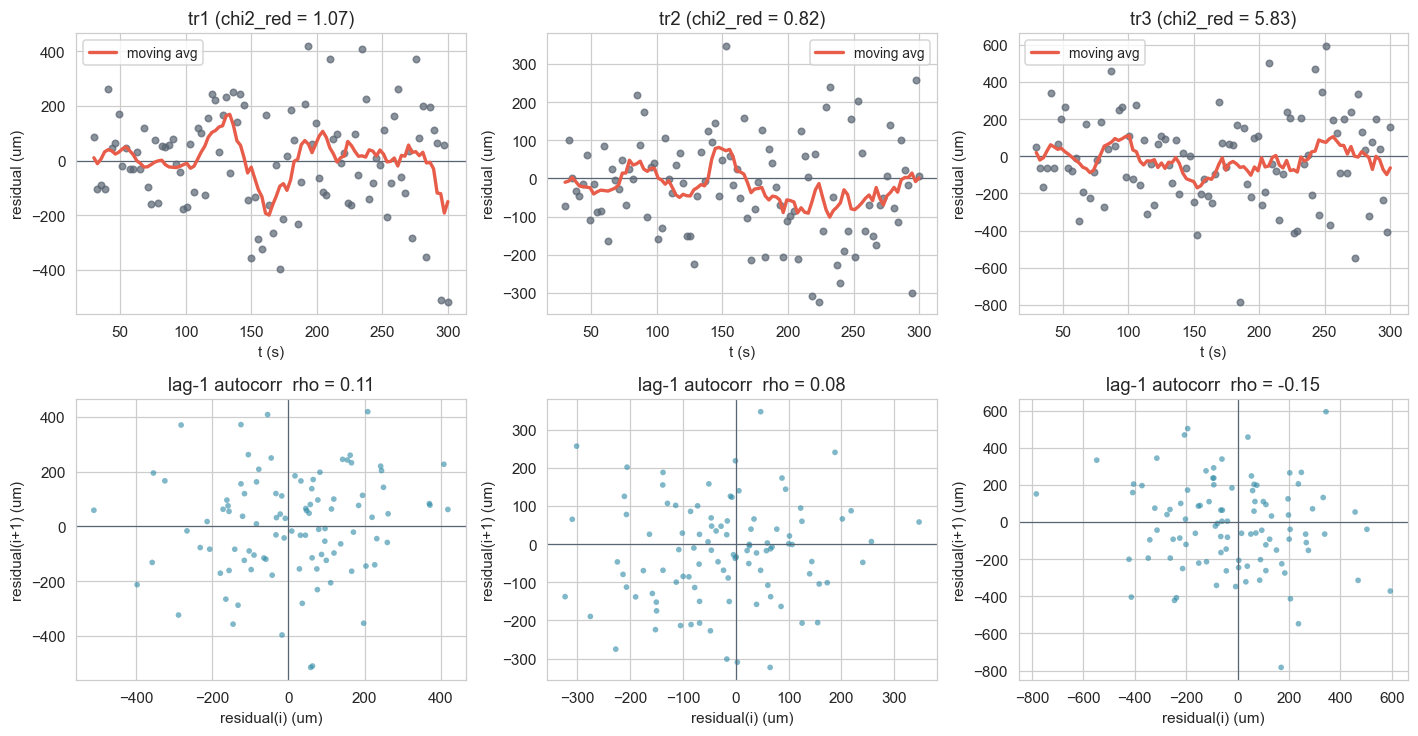

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.8))


for col_idx, name in enumerate(tr):
    f = fits[name]

    l_pred = washburn_l(f['t'], f['r'], gamma_tr, phi_tr, eta_tr)

    resid = f['l'] - l_pred



    # row 0: residual vs t with moving average
    ax = axes[0, col_idx]

    ax.scatter(f['t'], resid * 1e6, s=18, color=NEUTRAL, alpha=0.7)

    ax.axhline(0, color=NEUTRAL, lw=0.8)

    order = np.argsort(f['t'])

    smooth = uniform_filter1d(resid[order], size=10) * 1e6

    ax.plot(f['t'][order], smooth, color=HIGHLIGHT, lw=2.2, label='moving avg')

    ax.set_xlabel('t (s)')

    ax.set_ylabel('residual (um)')

    ax.set_title('{} (chi2_red = {:.2f})'.format(name, f['chi2_red']))

    ax.legend(fontsize=9)


    
    # row 1: lag-1 autocorrelation
    ax = axes[1, col_idx]

    sorted_r = resid[np.argsort(f['t'])]

    ax.scatter(sorted_r[:-1] * 1e6, sorted_r[1:] * 1e6, s=14, alpha=0.6,
               color=ACCENT, edgecolor='none')
    
    ax.axhline(0, color=NEUTRAL, lw=0.8)

    ax.axvline(0, color=NEUTRAL, lw=0.8)

    rho = np.corrcoef(sorted_r[:-1], sorted_r[1:])[0, 1]

    ax.set_xlabel('residual(i) (um)')

    ax.set_ylabel('residual(i+1) (um)')
    
    ax.set_title('lag-1 autocorr  rho = {:.2f}'.format(rho))

plt.tight_layout()
plt.show()


The residuals look similar across all three files, so Washburn is not actually failing on tr3. 

The inflated chi-squared is coming from the reported dL values being too small for some points - underestimated uncertainty produces the same warning sign as a bad fit. 

Checking the dL distributions directly shows which points are the problem.

In [53]:
print('{:<5}  {:<14}  {:<12}  {:<10}  {}'.format('file', 'dL min (um)', 'dL median', 'dL max', 'residual std'))



for name, f in fits.items():
    dl_um = f['dl'] * 1e6

    l_pred = washburn_l(f['t'], f['r'], gamma_tr, phi_tr, eta_tr)

    res_um = (f['l'] - l_pred) * 1e6
    
    print('{:<5} {:>10.0f} {:>8.0f}  {:>8.0f}  {:>10.0f} um'.format(
        name, dl_um.min(), np.median(dl_um), dl_um.max(), res_um.std()))


file   dL min (um)     dL median     dL max      residual std
tr1           46      390       851         185 um
tr2           55      403       905         129 um
tr3            7      422       825         236 um


tr3's dL values are reported as tiny as 7 µm in some places, which is over six times smaller than anything seen in tr1 or tr2.

When the actual residual at one of those points is around 50 µm, the chi-squared formula divides by the reported uncertainty squared - so a small dL blows the contribution up enormously. 

A handful of these over-optimistic uncertainty estimates are responsible for almost the entire chi-squared inflation.

The residuals themselves are completely normal. Washburn fits tr3 just as well as the other two files. The only thing wrong is that whoever recorded the uncertainties for tr3 was overly confident on a few measurements.

## Summary

| Question | Result |
|---|---|
| Does Washburn hold? | Yes - R^2 = 0.9996 when r is known. Slopes all close to 0.5. Residuals clean. |
| Pore radii | ~300 / 500 / 800 nm for Rich Tea / Hobnob / Digestive. All three significantly different. |
| GMM on unlabelled data | Recovers the same three modes without using any labels |
| Can ML identify biscuits? | Yes - 96% with r_eff, 81% without |
| Can ML beat Washburn at predicting L? | No - both plateau at R² ≈ 0.79 without biscuit identity |
| Hybrid pipeline | R² = 0.985 with honest error bars |
| Unknown biscuits | tr1 >> Hobnob, tr2 >> Rich Tea, tr3 >> Digestive |
| Why is tr3's X^2 high? | A few unrealistically small dL values in the file. The fit itself is fine. |






The main takeaway is that ML did not replace the physics,it filled the one gap the physics had. 

Washburn is excellent once you know the pore radius, but you rarely do. 

The classifier supplies that missing piece, and combining the two outperforms either on its own. 

That idea generalises well beyond biscuits.